--2026-05-06 21:37:01--  https://raw.githubusercontent.com/MicrosoftDocs/mslearn-introduction-to-machine-learning/main/Data/ml-basics/grades.csv
Auflösen des Hostnamens raw.githubusercontent.com (raw.githubusercontent.com)… 2606:50c0:8002::154, 2606:50c0:8001::154, 2606:50c0:8000::154, ...
Verbindungsaufbau zu raw.githubusercontent.com (raw.githubusercontent.com)|2606:50c0:8002::154|:443 … verbunden.
HTTP-Anforderung gesendet, auf Antwort wird gewartet … 200 OK
Länge: 322 [text/plain]
Wird in »grades.csv« gespeichert.

grades.csv          100%[===================>]     322  --.-KB/s    in 0s      

2026-05-06 21:37:01 (6,40 MB/s) - »grades.csv« gespeichert [322/322]

         Name  StudyHours  Grade  Passed
0         Dan       10.00   50.0   False
1       Joann       11.50   50.0   False
2       Pedro        9.00   47.0   False
3       Rosie       16.00   97.0    True
4       Ethan        9.25   49.0   False
5       Vicky        1.00    3.0   False
6    Frederic       11.50   53.0   Fa

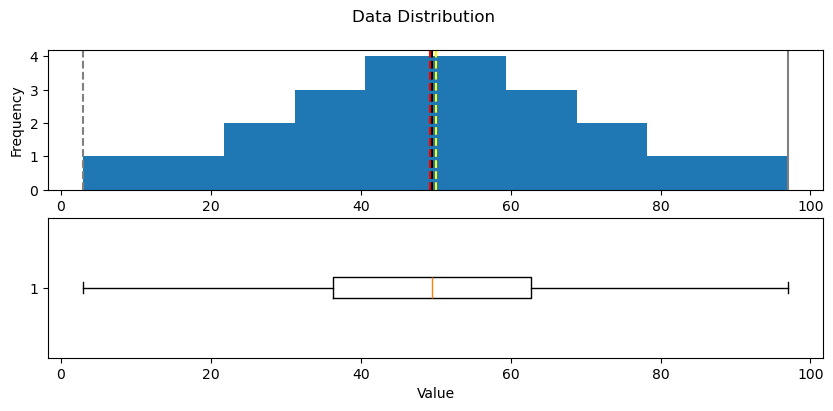

In [2]:
import pandas as pd
from matplotlib import pyplot as plt

# Load data from a .csv file
!wget -O grades.csv https://raw.githubusercontent.com/MicrosoftDocs/mslearn-introduction-to-machine-learning/main/Data/ml-basics/grades.csv
df_students = pd.read_csv('grades.csv', delimiter=',', header= 'infer')

# Remove any rows with missing values
df_students = df_students.dropna(axis=0, how='any')

# Calculate who passed, assuming 60 is the passing grade or the neede grade to pass
passes = pd.Series(df_students.Grade >= 60) 
# passes = pd.Series(df_students['Grade'] >= 60)

# Save who passed to the Pandasd dataframe
df_students = pd.concat([df_students, passes.rename('Passed')], axis=1)

# Print the result out into this notebook
print(df_students)

def show_distribution(data):
    """
    This function makes a distribution (graph) and displays it.
    """
    # Get the statistics for the data
    min_val = data.min()
    max_val = data.max()
    mean_val = data.mean()
    median_val = data.median()
    mode_val = data.mode()[0]

    # Create a figure for 2 subplots (2 rows, 1 column)
    fig, ax = plt.subplots(2, 1, figsize=(10, 4))

    # Plot the histogram
    ax[0].hist(data)
    ax[0].set_ylabel('Frequency')

    # Add lines for the mean, median, and mode 
    ax[0].axvline
    ax[0]. axvline(x=min_val, color='gray', linestyle='dashed')
    ax[0]. axvline(x=mode_val, color='yellow', linestyle='dashed')
    ax[0]. axvline(x=mean_val, color='red', linestyle='dashed')
    ax[0]. axvline(x=median_val, color='black', linestyle='dashed')
    ax[0]. axvline(x=max_val, color='gray')
    
    # Plot the boxplot
    ax[1]. boxplot(data, vert=False)
    ax[1]. set_xlabel('Value')
    
    # Add a title to the figure
    plt.suptitle('Data Distribution')
    
    # Show the figure
    plt.show()

show_distribution(df_students.Grade)

    

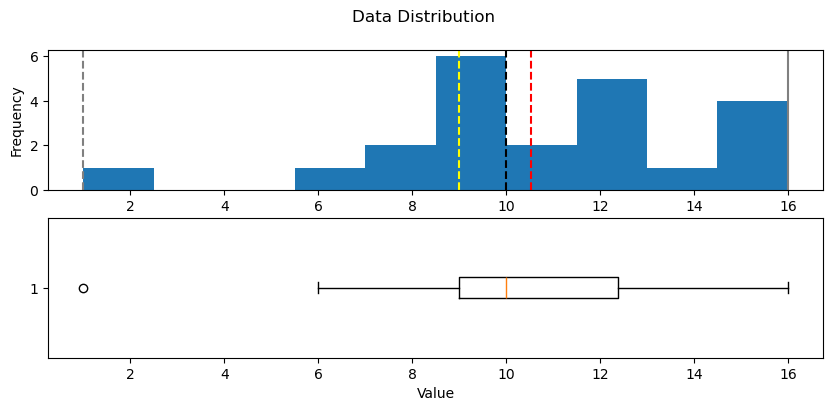

In [3]:
show_distribution(df_students.StudyHours)

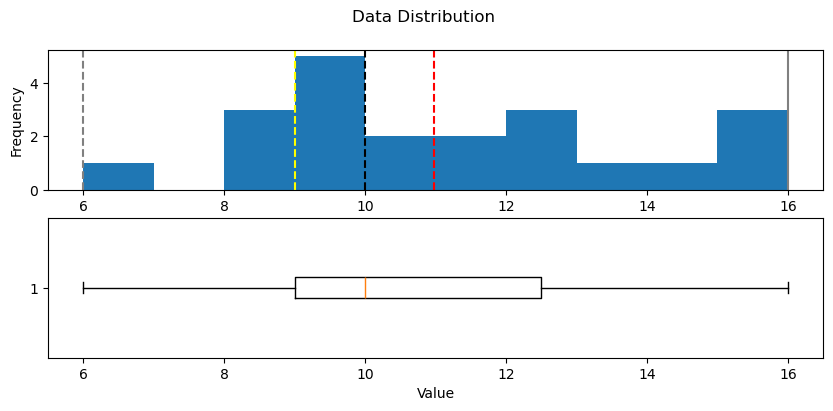

In [5]:
# Show the distribution of study hours after removal of outliers (greater than 1 hour)
col = df_students[df_students['StudyHours']>1]['StudyHours']
show_distribution(col)

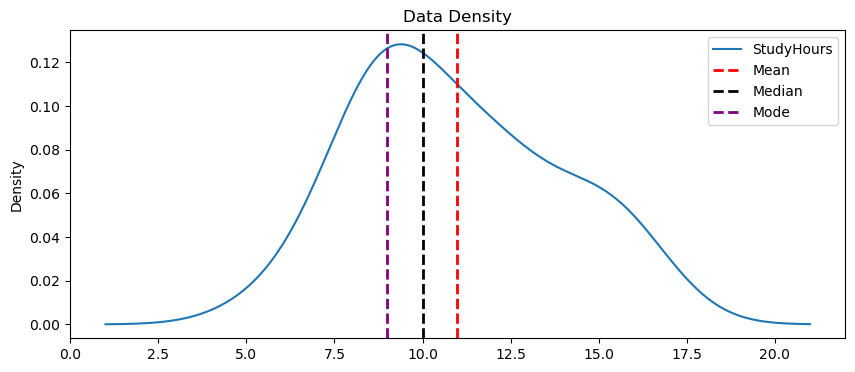

In [8]:
def show_density(data):
    fig = plt.figure(figsize=(10, 4))
    # Plot the density of the data
    data.plot.density()

    # Add a title and labels to the figure
    plt.title('Data Density')

    # Show the mean, median and mode as vertical lines on the density plot
    mean_val = data.mean()
    median_val = data.median()
    mode_val = data.mode()[0]
    plt.axvline(x=data.mean(), color='red', linestyle='dashed', linewidth=2, label='Mean')
    plt.axvline(x=data.median(), color='black', linestyle='dashed', linewidth=2, label='Median')
    plt.axvline(x=data.mode()[0], color='purple', linestyle='dashed', linewidth=2, label='Mode')
    plt.legend()

    plt.show()

# Show the density of study hours after removal of outliers (greater than 1 hour)
col = df_students[df_students['StudyHours']>1]['StudyHours']
show_density(col)

In [12]:
import math
mean = df_students.StudyHours.mean()
variance = 0
for hours in df_students.StudyHours:
    variance = variance + ((mean - hours)**2)
    
variance = variance/df_students.shape[0]
std = math.sqrt(variance)
print(f"Nbr of students: {df_students.shape[0]}, Variance: {variance}, Std Dev: {std}")


Nbr of students: 22, Variance: 11.607438016528924, Std Dev: 3.4069690366260925


In [13]:
for col_name in ['Grade', 'StudyHours']:
    col = df_students[col_name]
    rng = col.max() - col.min()
    var = col.var()
    std = col.std()
    print(f'\n{col_name}:\n - Range: {rng}\n - Variance: {var}\n - Std. Dev: {std}')


Grade:
 - Range: 94.0
 - Variance: 472.53679653679666
 - Std. Dev: 21.73791150356438

StudyHours:
 - Range: 15.0
 - Variance: 12.160173160173159
 - Std. Dev: 3.487143983286775


In [14]:
print(f"68% of the students' grades are between {df_students.Grade.mean() - df_students.Grade.std()} and {df_students.Grade.mean() + df_students.Grade.std()}")

68% of the students' grades are between 27.4439066782538 and 70.91972968538256


In [15]:
df_students.describe()

,StudyHours,Grade
count,22.000000,22.000000
mean,10.522727,49.181818
std,3.487144,21.737912
min,1.000000,3.000000
25%,9.000000,36.250000
50%,10.000000,49.500000
75%,12.375000,62.750000
max,16.000000,97.000000


<Axes: title={'center': 'StudyHours'}, xlabel='Passed'>

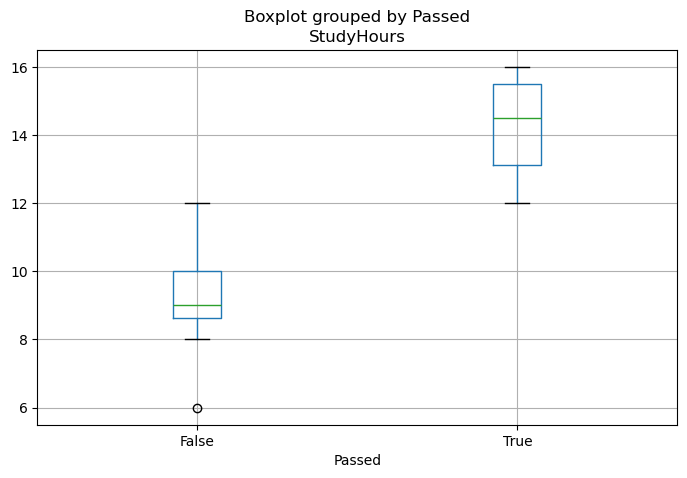

In [19]:
df_sample = df_students[df_students.StudyHours > 1]
df_sample. boxplot(column='StudyHours', by='Passed', figsize=(8, 5))

<Axes: xlabel='Name'>

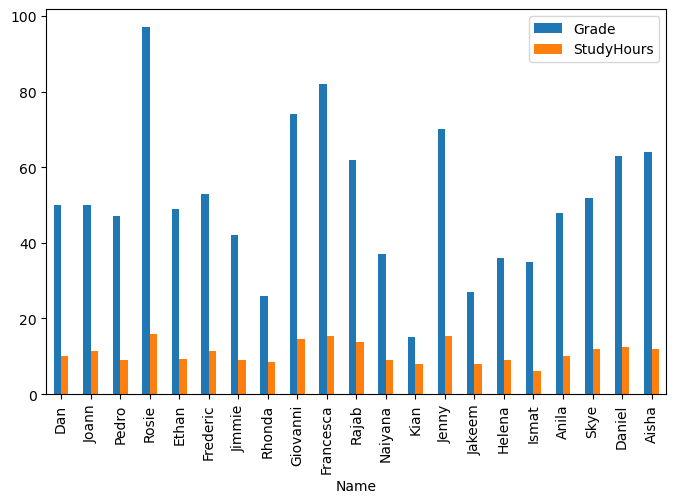

In [21]:
df_sample.plot(x = 'Name', y = ['Grade', 'StudyHours'], kind='bar', figsize=(8, 5))

## Normalizing ranges
The bar chart is kind of meaningless and the reason is that the scales for these numeric values are different.  
The Max grade is 97, whereas the max value of study hours is 16. They're not on the same scale. So we can't actually compare these values like this. We have to normalize the range for these values.
Here comes **MinMaxScaler** to the rescue.

<Axes: xlabel='Name'>

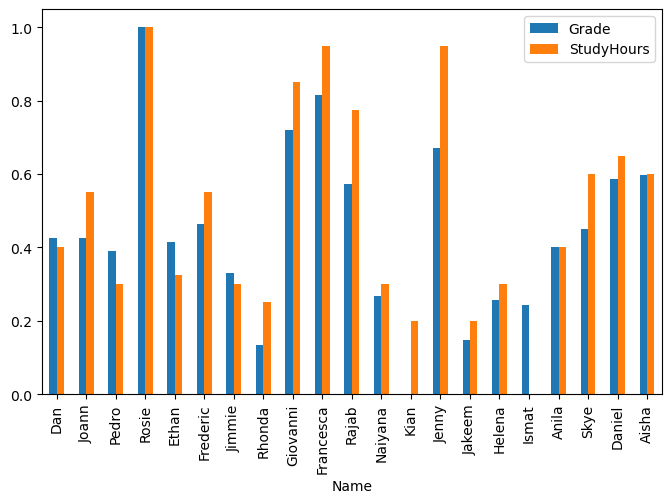

In [35]:
# Using MinMaxScaler to normalize the data
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df_normalized = df_sample[['Name', 'Grade', 'StudyHours']].copy()
df_normalized[['Grade', 'StudyHours']] = scaler.fit_transform(df_normalized[['Grade', 'StudyHours']])
df_normalized.plot(x = 'Name', y = ['Grade', 'StudyHours'], kind='bar', figsize=(8, 5))

# Calculating Correlation value
Correlation measures how strongly two variables move together. In this example, a correlation of `0.91` between study hours and grade suggests a very strong positive relationship: as study hours increase, grades tend to increase too.
## Main point
* Correlation ranges from  -1  to  1
* 1  means a perfect positive relationship.
* -1  means a perfect negative relationship.
* 0  means no linear relationship.
## Interpretation here
A value of  0.91  is very close to  1 , so the two variables are strongly related. That means students who study more usually get higher grades in this dataset.
## Important caution
This does not prove **causation**.
It is tempting to say “studying more causes higher grades,” but correlation alone cannot prove that. There could be other factors involved, and the relationship might also be influenced by things we are not measuring.
## Simple takeaway
The data shows a strong connection between study time and grade, but it does not automatically tell us that one directly causes the other.

In [23]:
df_normalized.Grade.corr(df_normalized.StudyHours)

0.9117666413789677

<Axes: title={'center': 'Study Time vs. Grade'}, xlabel='StudyHours', ylabel='Grade'>

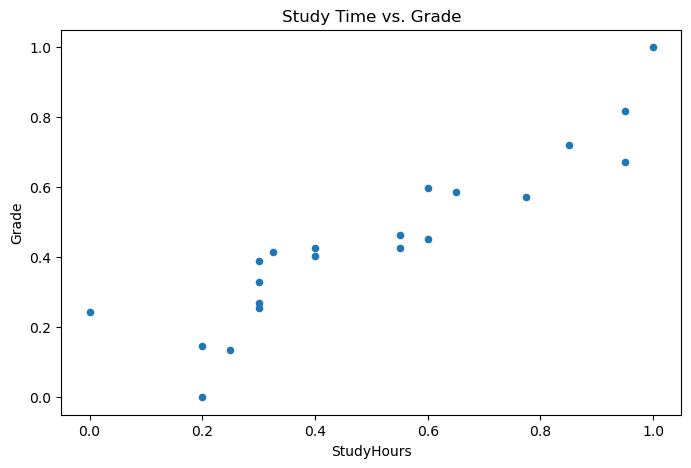

In [24]:
df_normalized.plot.scatter(title = 'Study Time vs. Grade', x = 'StudyHours', y = 'Grade', figsize=(8, 5))

# Using regression lines
A **regression line** is a line of best fit used to model the relationship between two variables, here  *StudyHours*  and  *Grade* . It helps show the trend in the scatter plot and lets you predict  Grade  from  StudyHours .
## Core idea
The line is usually written as:
* x  = input variable, here  StudyHours
* y  = output variable, here  Grade
* m  = slope, how steep the line is
* b  = intercept, where the line crosses the y-axis
## Error and best fit
For each point, the regression line gives a predicted value .
The error is the difference between the actual value and the predicted value:

Because positive and negative errors can cancel each other out, the errors are squared. This gives the least squares method, which tries to minimize the total squared error and produce the best fitting line.
Why it matters
* A positive slope means more study hours usually go with higher grades.
* The regression line makes the pattern easier to see than the raw dots alone.
* It also gives a simple way to estimate a grade for a given number of study hours.
## In Python
Instead of calculating slope and intercept by hand, Python can do it for you using statistical tools. You prepare the two columns, `StudyHours` and `Grade`, then compute the **regression line** from them.
So the main takeaway is: correlation tells you how strongly two variables are related, and regression gives you a line that models that relationship.

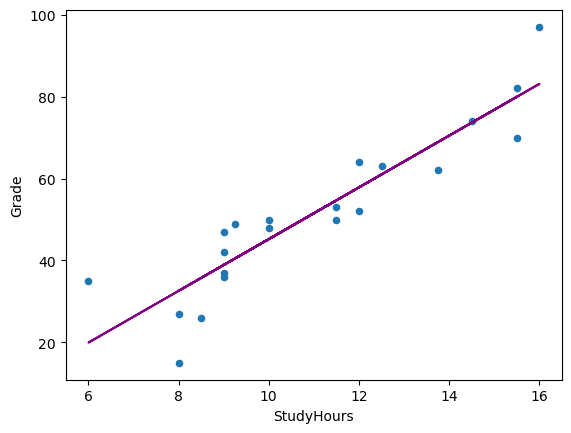

In [34]:
from scipy import stats
df_regression = df_sample[['Grade', 'StudyHours' ]].copy()
m, b, r, P, se = stats.linregress(df_regression["StudyHours"], df_regression[ "Grade" ])
df_regression['fx'] = (m * df_regression['StudyHours' ]) + b

df_regression['error']  = df_regression['fx'] - df_regression['Grade']
df_regression. plot.scatter(x='StudyHours', y='Grade')
plt.plot(df_regression['StudyHours'], df_regression['fx'], color='purple')
plt.show()
